In [ ]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval (x) if pd.notna(x) else x)


## 1. COUNTS OF JOBS PER COUNTRY

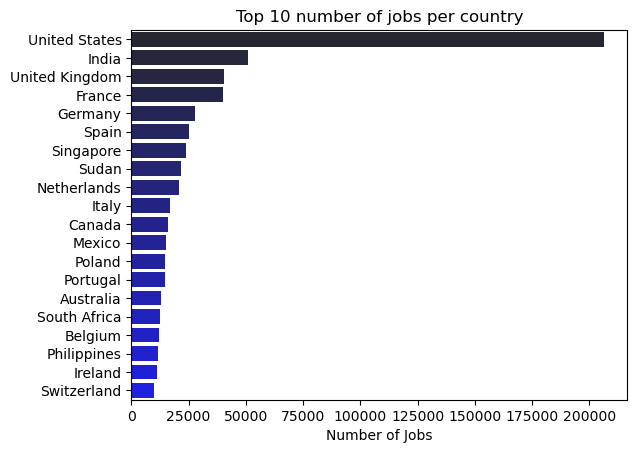

In [4]:
df_country = df['job_country'].value_counts(ascending=False).head(20).reset_index()
df_country.columns = ['Country', 'Number of jobs']
sns.barplot(data=df_country ,x='Number of jobs', y='Country', hue='Country', palette='dark:b')

plt.title('Top 10 number of jobs per country')
plt.ylabel('')
plt.xlabel('Number of Jobs')
plt.show()


## 2. COUNTS OF JOBS PER COMPANY

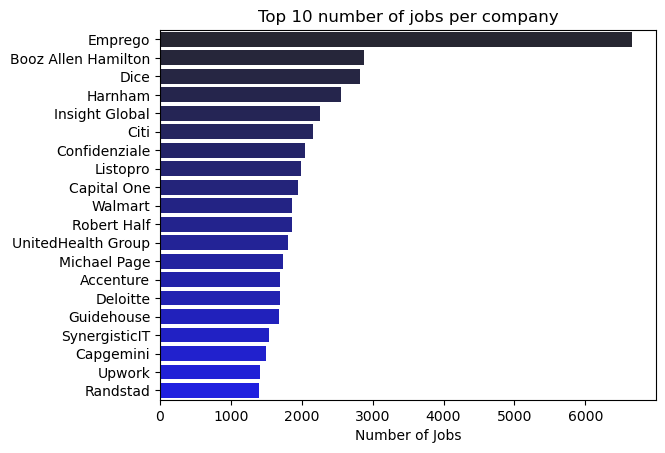

In [5]:
df_country = df['company_name'].value_counts(ascending=False).head(20).reset_index()
df_country.columns = ['Country', 'Number of jobs']
sns.barplot(data=df_country ,x='Number of jobs', y='Country', hue='Country', palette='dark:b')

plt.title('Top 10 number of jobs per company')
plt.ylabel('')
plt.xlabel('Number of Jobs')
plt.show()

## 3. COUNTS OF JOBS PER LOCATION

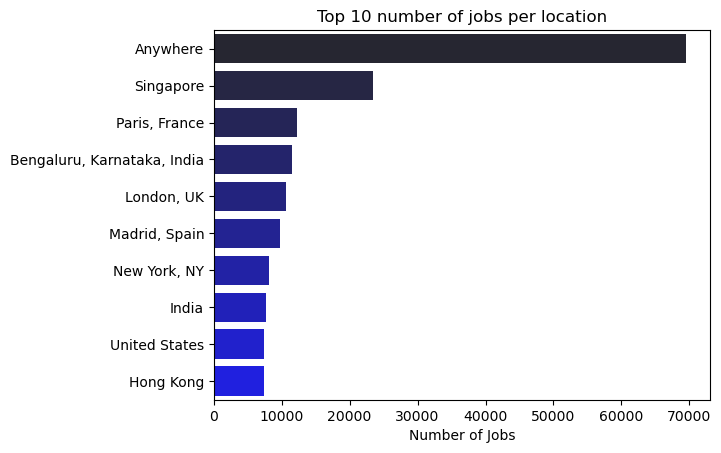

In [6]:
df_country = df['job_location'].value_counts(ascending=False).head(10).reset_index()
df_country.columns = ['Country', 'Number of jobs']
sns.barplot(data=df_country ,x='Number of jobs', y='Country', hue='Country', palette='dark:b')

plt.title('Top 10 number of jobs per location')
plt.ylabel('')
plt.xlabel('Number of Jobs')
plt.show()


## 4. COUNTS OF JOBS PER COMPANIES FOR DATA ANALYST IN THE US

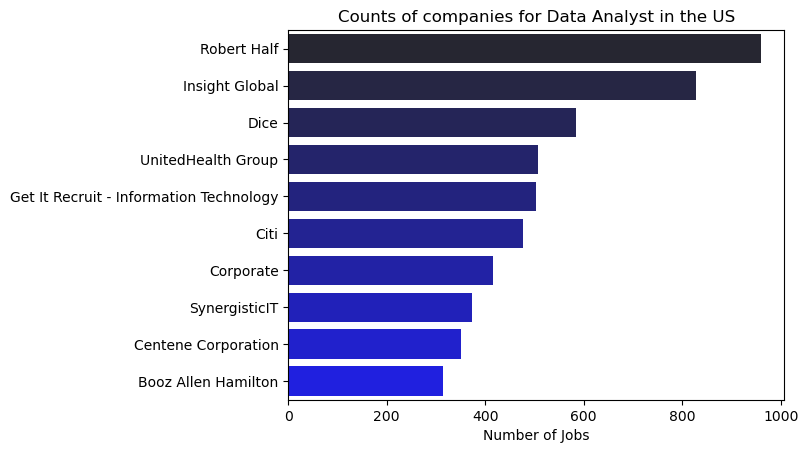

In [7]:
df_country = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')] ['company_name'].value_counts(ascending=False).head(10).reset_index()
df_country.columns = ['Country', 'Number of jobs']
sns.barplot(data=df_country ,x='Number of jobs', y='Country', hue='Country', palette='dark:b')

plt.title('Counts of companies for Data Analyst in the US')
plt.ylabel('')
plt.xlabel('Number of Jobs')
plt.show()

## 5. COUNTS OF TOP SKILLS IN JOB POSTING

In [96]:
# will do this only if we need the amt to percentage
df_grp.sort_values(by='skill count', ascending=False, inplace=True)
df_grp


,job_skills,job_title_short,skill count
1374,sql,Data Engineer,12993
1088,python,Data Engineer,11568
1089,python,Data Scientist,9248
1327,spark,Data Engineer,7157
103,aws,Data Engineer,6993
...,...,...,...
203,chef,Senior Data Analyst,1
1247,seaborn,Cloud Engineer,1
307,db2,Cloud Engineer,1
311,db2,Machine Learning Engineer,1


In [84]:
job_final=df_jts['job_title_short'].value_counts().reset_index(name='job_total').head(3)
job_final

,job_title_short,job_total
0,Data Engineer,19062
1,Data Scientist,13279
2,Data Analyst,6121


In [91]:
df_per= pd.merge(df_grp, job_final,how='left', on='job_title_short')
df_per['skill_per']= df_per['skill count'] / df_per['job_total']*100
df_per

,job_skills,job_title_short,skill count,job_total,skill_per
0,sql,Data Engineer,12993,19062.0,68.161788
1,python,Data Engineer,11568,19062.0,60.686182
2,python,Data Scientist,9248,13279.0,69.643798
3,spark,Data Engineer,7157,19062.0,37.545903
4,aws,Data Engineer,6993,19062.0,36.685552
...,...,...,...,...,...
1684,esquisse,Data Scientist,1,13279.0,0.007531
1685,node.js,Senior Data Analyst,1,NaN,NaN
1686,matlab,Cloud Engineer,1,NaN,NaN
1687,fastapi,Cloud Engineer,1,NaN,NaN


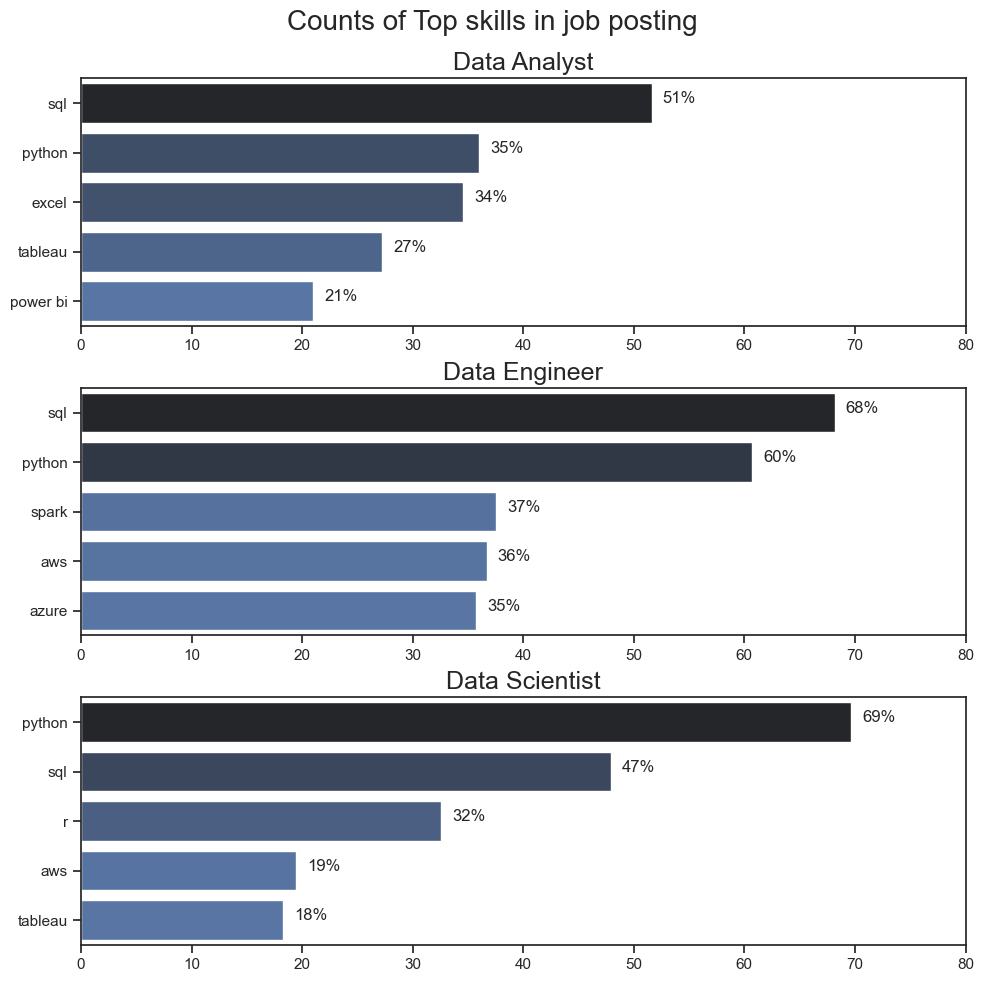

In [135]:
df_jts = df[df['job_country']== 'India']
df_explode=df_jts.explode('job_skills')
df_explode[['job_title', 'job_skills']]
df_grp = df_explode.groupby(['job_skills', 'job_title_short']).size()
df_grp = df_grp.reset_index(name='skill count')
df_grp.sort_values(by='skill count', ascending=False, inplace=True)

job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

fig,ax = plt.subplots(len(job_titles),1 , figsize=(10,10))
sns.set_theme(style='ticks')
for i, job_titles in enumerate(job_titles):
    df_plot = df_per[df_per['job_title_short'] == job_titles].head(5)
   # df_plot.plot(kind='barh', x='job_skills', y='skill_per', ax=ax[i], title=job_titles)
    sns.barplot(data = df_plot, x='skill_per', y='job_skills', ax=ax[i],hue='skill count', palette='dark:b_r')
    ax[i].set_ylabel('')
    ax[i].set_title(job_titles, fontsize=18)
    ax[i].legend().set_visible(False)
    ax[i].set_xlabel('')
    ax[i].set_xlim(0, 80)

    for n, v in enumerate(df_plot['skill_per']):
        ax[i].text(v + 1, n, f'{int(v)}%')

fig.suptitle('Counts of Top skills in job posting', fontsize=20)
fig.tight_layout(h_pad=0.5)
plt.show()